## Comparação dos resultados do TCC: amostra principal (n = 54) × amostra ampliada (n = 69)

Este notebook refaz **somente as análises apresentadas no TCC** em duas amostras e mostra os resultados lado a lado:

- **Amostra principal (n = 54; 35 jovens e 19 mais velhos):** critério estrito (resultados atuais do TCC).
- **Amostra ampliada (n = 69; 46 jovens e 23 mais velhos):** campos vazios não excluem e BSL-23 comportamental ≤ 1 (dataset gerado em `01_redes_amostra_ampliada`).

O código de cada análise é o mesmo dos notebooks originais (`01_eda/03`, `02_pca/03` e `04`, `03_classification/07`, `08` e `09`). A coluna da amostra principal deve reproduzir os números atuais do TCC. Nenhum arquivo da análise principal é alterado; as figuras são salvas em `figures/amostra_ampliada/`.

### Configuração

In [1]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from IPython.display import Image, display
from joblib import Parallel, delayed
from plotly.subplots import make_subplots
from scipy.stats import false_discovery_control, mannwhitneyu
from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    StratifiedKFold,
    cross_val_predict,
    cross_validate,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

DATA = Path("../../data")
FIG_DIR = Path("../../figures/amostra_ampliada")
FIG_DIR.mkdir(parents=True, exist_ok=True)

SAMPLE_PATHS = {
    "principal": DATA / "processed" / "dataset_features.parquet",
    "ampliada": DATA / "expanded" / "dataset_features.parquet",
}

RANDOM_STATE = 42
N_SPLITS = 5
N_PERM = 5000
N_REPEATS = 20
N_PERM_IMPORTANCE = 100
ALPHA_BONF = 0.05 / 4

YOUNG_AGES = {"20-25", "25-30", "30-35", "35-40"}
OLDER_AGES = {"55-60", "60-65", "65-70", "70-75", "75-80"}
NODE_PREFIXES = ("degree_", "clustering_", "betweenness_", "hub_frequency_")
GLOBAL_FEATURES = ["edges_mean", "edges_std", "edges_cv"]
FEATURE_FAMILIES = {
    "degree": ("degree_",),
    "clustering": ("clustering_",),
    "betweenness": ("betweenness_",),
    "hub_frequency": ("hub_frequency_",),
    "global": tuple(GLOBAL_FEATURES),
}
EDUCATION_FIX = {"gymansium": "gymnasium"}


def load_sample(path: Path) -> pd.DataFrame:
    df = pd.read_parquet(path)
    df = df[df["condition"].isin(["EO", "EC"])].copy()
    assert not df.duplicated(["subject_id", "condition"]).any()
    df["age"] = df["age"].astype(str)
    df["age_group"] = np.where(df["age"].isin(OLDER_AGES), "older", np.where(df["age"].isin(YOUNG_AGES), "young", None))
    assert df["age_group"].notna().all()
    df["y"] = (df["age_group"] == "older").astype(int)
    return df.reset_index(drop=True)


samples = {}
for name, path in SAMPLE_PATHS.items():
    df = load_sample(path)
    subj = df.drop_duplicates("subject_id")
    n_y, n_o = int((subj["age_group"] == "young").sum()), int((subj["age_group"] == "older").sum())
    samples[name] = df
    print(f"{name}: {len(subj)} participantes ({n_y} jovens, {n_o} mais velhos), {len(df)} registros")

LABEL = {
    name: f"Amostra {name} (n = {df['subject_id'].nunique()})" for name, df in samples.items()
}
N_GROUP = {
    name: df.drop_duplicates("subject_id")["age_group"].value_counts().to_dict() for name, df in samples.items()
}


def side_by_side(tables: dict) -> pd.DataFrame:
    return pd.concat({LABEL[k]: v for k, v in tables.items()}, axis=1)


def fmt_num(x, spec):
    return "" if pd.isna(x) else format(x, spec).replace(".", ",")


# 600 px ≈ 16 cm (largura do texto no TCC): inserida nessa largura, fonte de 14 px ≈ 10,5 pt e linha de 2 px ≈ 1,5 pt
TCC_WIDTH = 600
TCC_FONT = dict(family="Arial", size=14, color="black")
TCC_AXIS = dict(showgrid=False, zeroline=False, showline=True, linecolor="black", linewidth=2, mirror=False,
                ticks="outside", tickcolor="black", tickwidth=2, title_font=TCC_FONT, tickfont=TCC_FONT)


def tcc_style(fig):
    fig.update_xaxes(**TCC_AXIS)
    fig.update_yaxes(**TCC_AXIS)
    fig.update_annotations(font=TCC_FONT)
    fig.update_layout(
        title=None,
        font=TCC_FONT,
        separators=",.",
        template="simple_white",
        paper_bgcolor="rgba(0,0,0,0)",
        plot_bgcolor="rgba(0,0,0,0)",
        showlegend=False,
    )
    return fig


def save_and_show(fig, name: str, height: int, width: int = TCC_WIDTH):
    tcc_style(fig)
    path = FIG_DIR / f"{name}.png"
    started = time.time()
    try:
        fig.write_image(path, width=width, height=height, scale=4)
    except RuntimeError:
        # o Kaleido às vezes falha ao fechar o navegador depois de já ter gravado o PNG
        if not (path.exists() and path.stat().st_mtime >= started):
            raise
    try:
        display(Image(filename=path, width=width))
        print(f"Salvo: {path}")
    except (ValueError, RuntimeError) as err:
        fig.update_layout(width=width, height=height)
        fig.write_html(path.with_suffix(".html"))
        print(f"PNG indisponível ({err}); HTML: {path.with_suffix('.html')}")
        fig.show()

principal: 54 participantes (35 jovens, 19 mais velhos), 108 registros
ampliada: 69 participantes (46 jovens, 23 mais velhos), 138 registros


### Composição das amostras

Os 54 participantes da amostra principal estão todos contidos na ampliada; os 15 adicionais são 11 jovens e 4 mais velhos.

In [2]:
def composition(df: pd.DataFrame) -> pd.Series:
    subj = df.drop_duplicates("subject_id")
    gender = subj["gender"].astype(float).map({1: "feminino", 2: "masculino"})
    return pd.Series({
        "Participantes": len(subj),
        "Adultos jovens": int((subj["age_group"] == "young").sum()),
        "Adultos mais velhos": int((subj["age_group"] == "older").sum()),
        "Registros (EO + EC)": len(df),
        "Jovens: feminino": int(((subj["age_group"] == "young") & (gender == "feminino")).sum()),
        "Mais velhos: feminino": int(((subj["age_group"] == "older") & (gender == "feminino")).sum()),
    })


pd.DataFrame({LABEL[k]: composition(df) for k, df in samples.items()})

,Amostra principal (n = 54),Amostra ampliada (n = 69)
Participantes,54,69
Adultos jovens,35,46
Adultos mais velhos,19,23
Registros (EO + EC),108,138
Jovens: feminino,8,10
Mais velhos: feminino,4,7


### Tabela 2: métricas de rede por grupo etário

Um valor por participante (média de EO e EC); Mann–Whitney bilateral; FDR de Benjamini–Hochberg nas cinco métricas; rank-biserial na ordem mais velhos versus jovens (negativo = menor nos mais velhos). A interação compara a diferença individual EO − EC entre os grupos.

In [3]:
GRAPH_METRICS = {
    "m_degree": ("degree_", "Grau médio por janela (normalizado)"),
    "m_sd_degree": ("sd_degree_", "Variabilidade temporal do grau (DP)"),
    "m_bin_clustering": ("bin_clustering_", "Agrupamento binário por janela"),
    "m_clustering": ("clustering_", "Agrupamento ponderado (REA)"),
    "m_betweenness": ("betweenness_", "Intermediação (REA, distância 1/peso)"),
}
# nomes sem os prefixos das métricas por eletrodo, para não entrarem no PCA nem nos modelos

for df in samples.values():
    for metric, (prefix, _) in GRAPH_METRICS.items():
        df[metric] = df[[c for c in df.columns if c.startswith(prefix)]].mean(axis=1)


def group_test(values: pd.Series) -> dict:
    values = values.dropna()
    older = values.xs("older", level="age_group")
    young = values.xs("young", level="age_group")
    u, p = mannwhitneyu(older, young, alternative="two-sided")
    return {
        "Mediana jovens": young.median(),
        "Mediana mais velhos": older.median(),
        "p": p,
        "Rank-biserial": 2 * u / (len(older) * len(young)) - 1,
    }


def age_metric_tests(df: pd.DataFrame):
    per_subject = df.pivot_table(index=["subject_id", "age_group"], columns="condition", values=list(GRAPH_METRICS))
    age_rows, inter_rows = {}, {}
    for metric, (_, label) in GRAPH_METRICS.items():
        eo, ec = per_subject[(metric, "EO")], per_subject[(metric, "EC")]
        age_rows[label] = group_test((eo + ec) / 2)
        inter_rows[label] = group_test(eo - ec)
    age, inter = pd.DataFrame(age_rows).T, pd.DataFrame(inter_rows).T
    age["p_FDR"] = false_discovery_control(age["p"])
    inter["p_FDR"] = false_discovery_control(inter["p"])
    return age, inter


tab2 = {k: age_metric_tests(df) for k, df in samples.items()}


def fmt_tab2(t: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame({
        "Mediana jovens": t["Mediana jovens"].map(lambda v: fmt_num(v, ".4g")),
        "Mediana mais velhos": t["Mediana mais velhos"].map(lambda v: fmt_num(v, ".4g")),
        "p_FDR": t["p_FDR"].map(lambda v: fmt_num(v, ".4f")),
        "Rank-biserial": t["Rank-biserial"].map(lambda v: fmt_num(v, "+.2f")),
    })


print("Tabela 2: média de EO e EC por participante")
display(side_by_side({k: fmt_tab2(age) for k, (age, _) in tab2.items()}))
print("Interação idade × condição (EO − EC por participante)")
display(side_by_side({k: fmt_tab2(inter) for k, (_, inter) in tab2.items()}))

Tabela 2: média de EO e EC por participante


Amostra principal (n = 54)  \
                                                  Mediana jovens   
Grau médio por janela (normalizado)                       0,6063   
Variabilidade temporal do grau (DP)                       0,2002   
Agrupamento binário por janela                            0,7677   
Agrupamento ponderado (REA)                               0,5911   
Intermediação (REA, distância 1/peso)                  7,868e-05   

                                                                   \
                                      Mediana mais velhos   p_FDR   
Grau médio por janela (normalizado)                0,5453  0,0056   
Variabilidade temporal do grau (DP)                0,1978  0,0658   
Agrupamento binário por janela                     0,7216  0,0056   
Agrupamento ponderado (REA)                        0,5285  0,0056   
Intermediação (REA, distância 1/peso)           0,0003297  0,0667   

                                                    Amostra ampliada (n = 69)  \
                                      Rank-biserial            Mediana jovens   
Grau médio por janela (normalizado)           -0,49                    0,6088   
Variabilidade temporal do grau (DP)           -0,32                    0,1996   
Agrupamento binário por janela                -0,49                    0,7686   
Agrupamento ponderado (REA)                   -0,49                    0,5932   
Intermediação (REA, distância 1/peso)         +0,31                 8,382e-05   

                                                                   \
                                      Mediana mais velhos   p_FDR   
Grau médio por janela (normalizado)                0,5477  0,0017   
Variabilidade temporal do grau (DP)                 0,199  0,1130   
Agrupamento binário por janela                     0,7278  0,0017   
Agrupamento ponderado (REA)                        0,5319  0,0017   
Intermediação (REA, distância 1/peso)           0,0003088  0,1035   

                                                     
                                      Rank-biserial  
Grau médio por janela (normalizado)           -0,50  
Variabilidade temporal do grau (DP)           -0,24  
Agrupamento binário por janela                -0,49  
Agrupamento ponderado (REA)                   -0,50  
Intermediação (REA, distância 1/peso)         +0,26

Interação idade × condição (EO − EC por participante)


Amostra principal (n = 54)  \
                                                  Mediana jovens   
Grau médio por janela (normalizado)                     -0,01165   
Variabilidade temporal do grau (DP)                      0,00294   
Agrupamento binário por janela                          -0,01116   
Agrupamento ponderado (REA)                             -0,01284   
Intermediação (REA, distância 1/peso)                          0   

                                                                   \
                                      Mediana mais velhos   p_FDR   
Grau médio por janela (normalizado)              -0,07025  0,0255   
Variabilidade temporal do grau (DP)              -0,00709  0,0356   
Agrupamento binário por janela                   -0,05709  0,0255   
Agrupamento ponderado (REA)                      -0,07353  0,0255   
Intermediação (REA, distância 1/peso)           0,0001217  0,0206   

                                                    Amostra ampliada (n = 69)  \
                                      Rank-biserial            Mediana jovens   
Grau médio por janela (normalizado)           -0,40                  -0,01303   
Variabilidade temporal do grau (DP)           -0,35                  0,001664   
Agrupamento binário por janela                -0,41                  -0,01178   
Agrupamento ponderado (REA)                   -0,39                   -0,0131   
Intermediação (REA, distância 1/peso)         +0,48                         0   

                                                                   \
                                      Mediana mais velhos   p_FDR   
Grau médio por janela (normalizado)              -0,07025  0,0086   
Variabilidade temporal do grau (DP)              -0,00709  0,0188   
Agrupamento binário por janela                   -0,05709  0,0086   
Agrupamento ponderado (REA)                      -0,07353  0,0086   
Intermediação (REA, distância 1/peso)           0,0001103  0,0086   

                                                     
                                      Rank-biserial  
Grau médio por janela (normalizado)           -0,43  
Variabilidade temporal do grau (DP)           -0,35  
Agrupamento binário por janela                -0,41  
Agrupamento ponderado (REA)                   -0,43  
Intermediação (REA, distância 1/peso)         +0,40

### Figura 6: grau, agrupamento binário e intermediação por grupo etário

Um ponto por participante (média de EO e EC). Uma figura por amostra (`fig6_metricas_idade_n54.png` e `fig6_metricas_idade_n69.png`); A: grau, B: agrupamento binário, C: intermediação.

Amostra principal (n = 54)


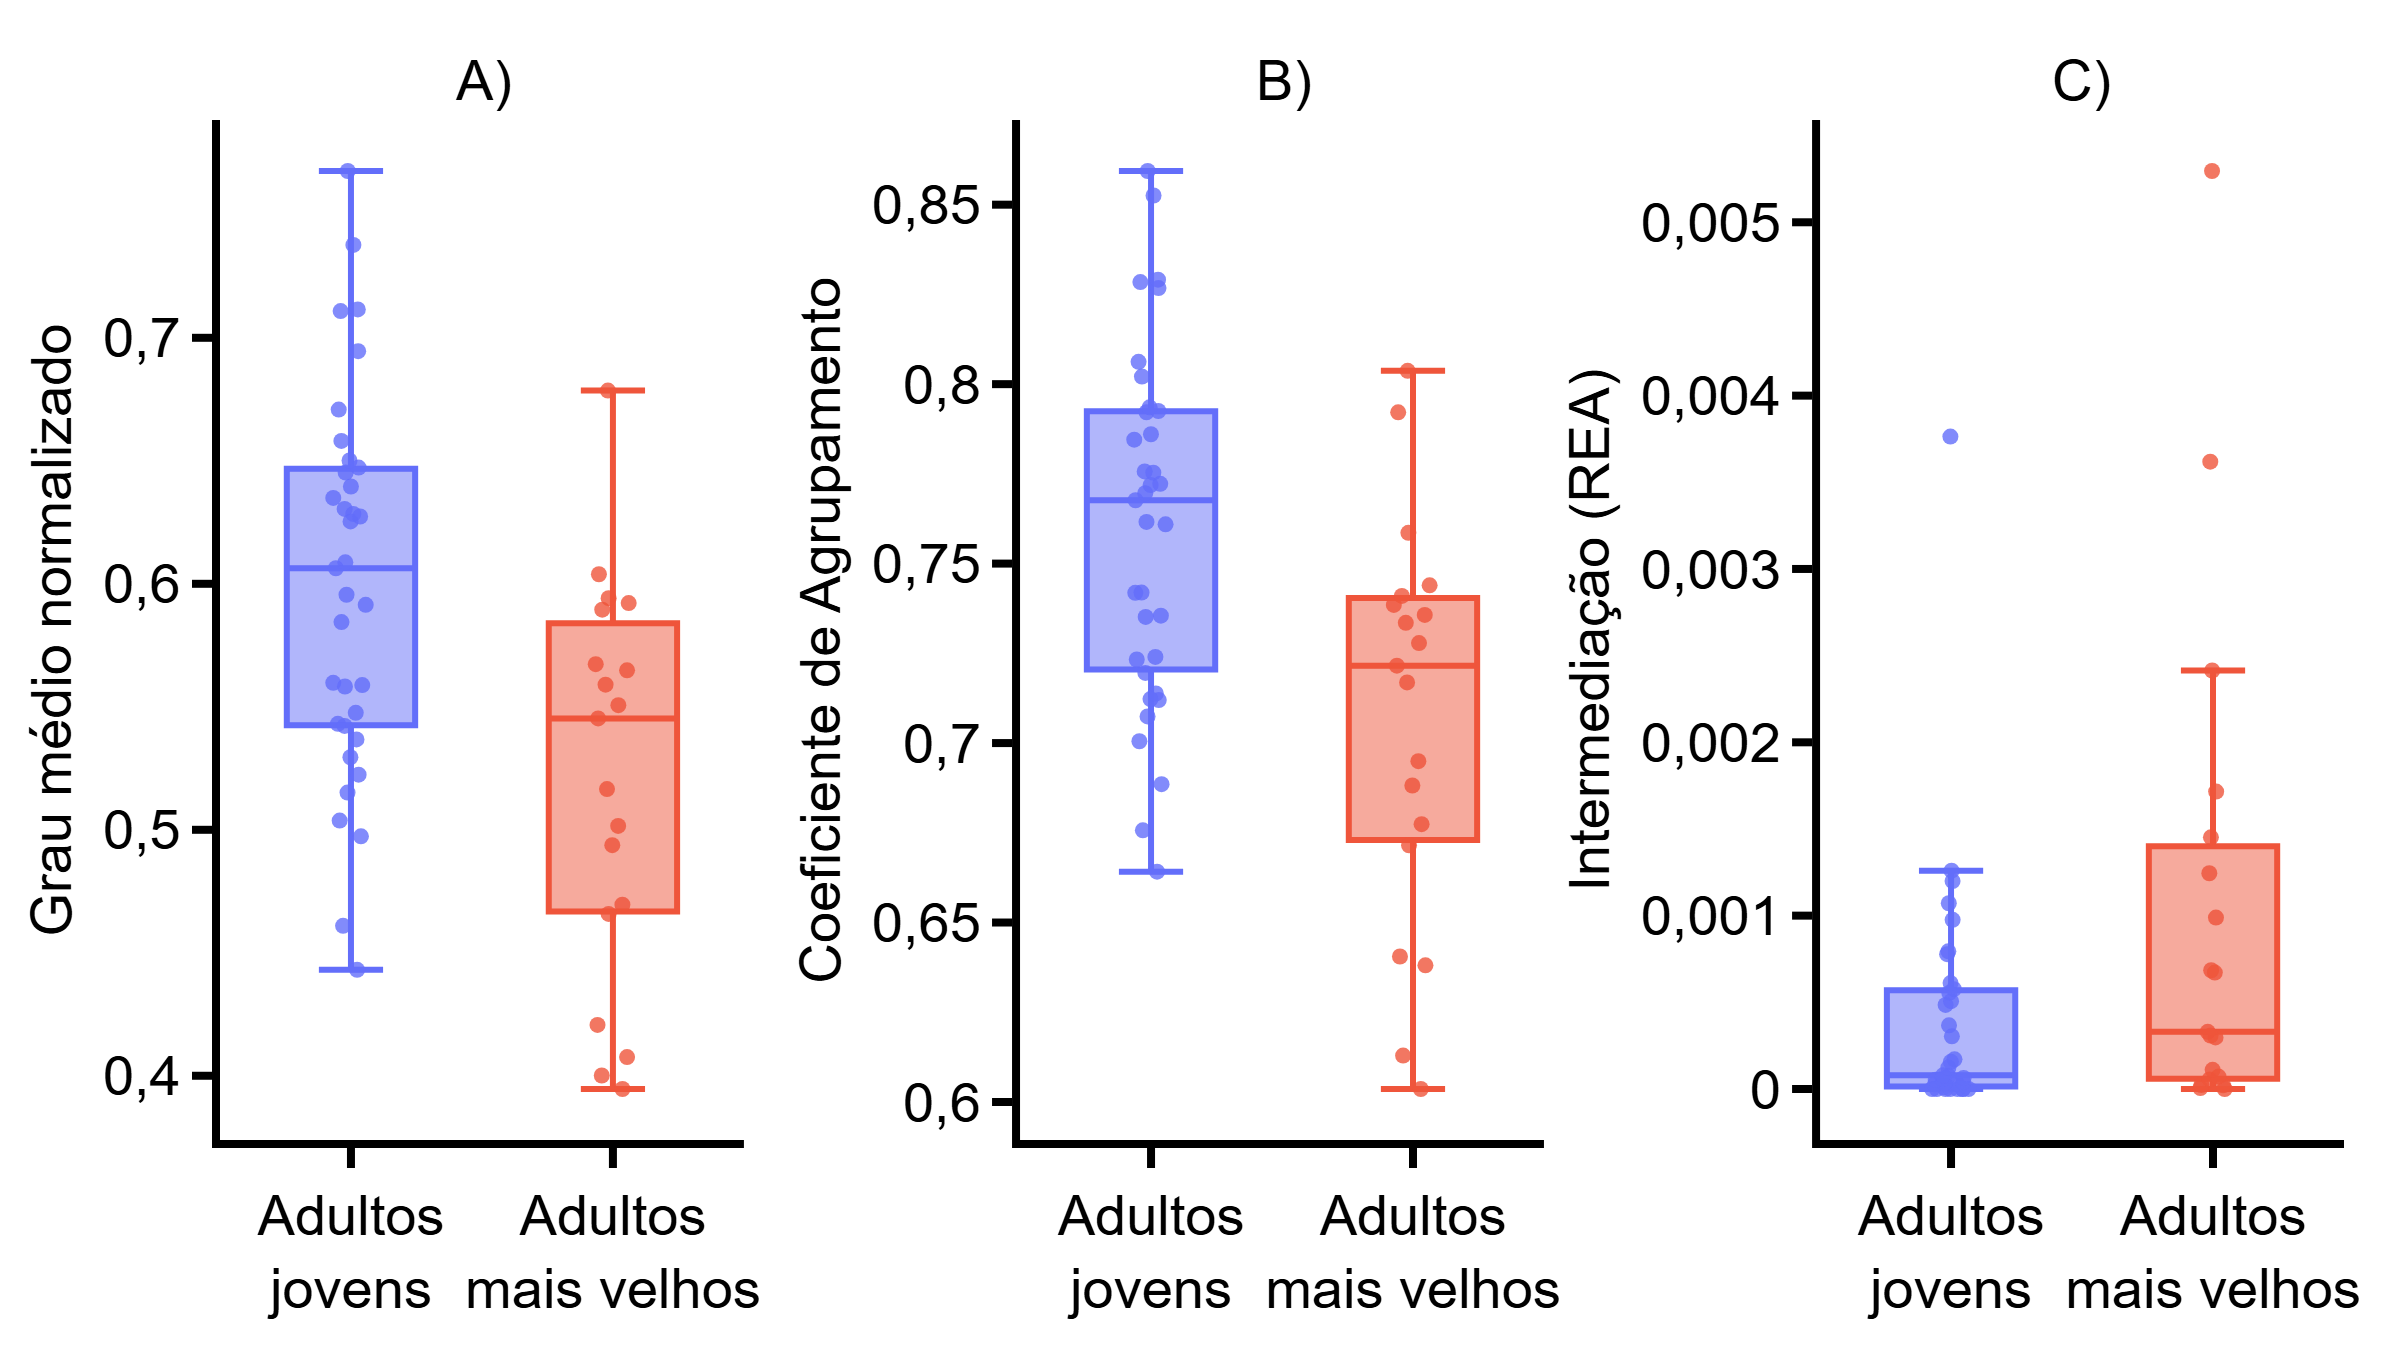

Salvo: ..\..\figures\amostra_ampliada\fig6_metricas_idade_n54.png
Amostra ampliada (n = 69)


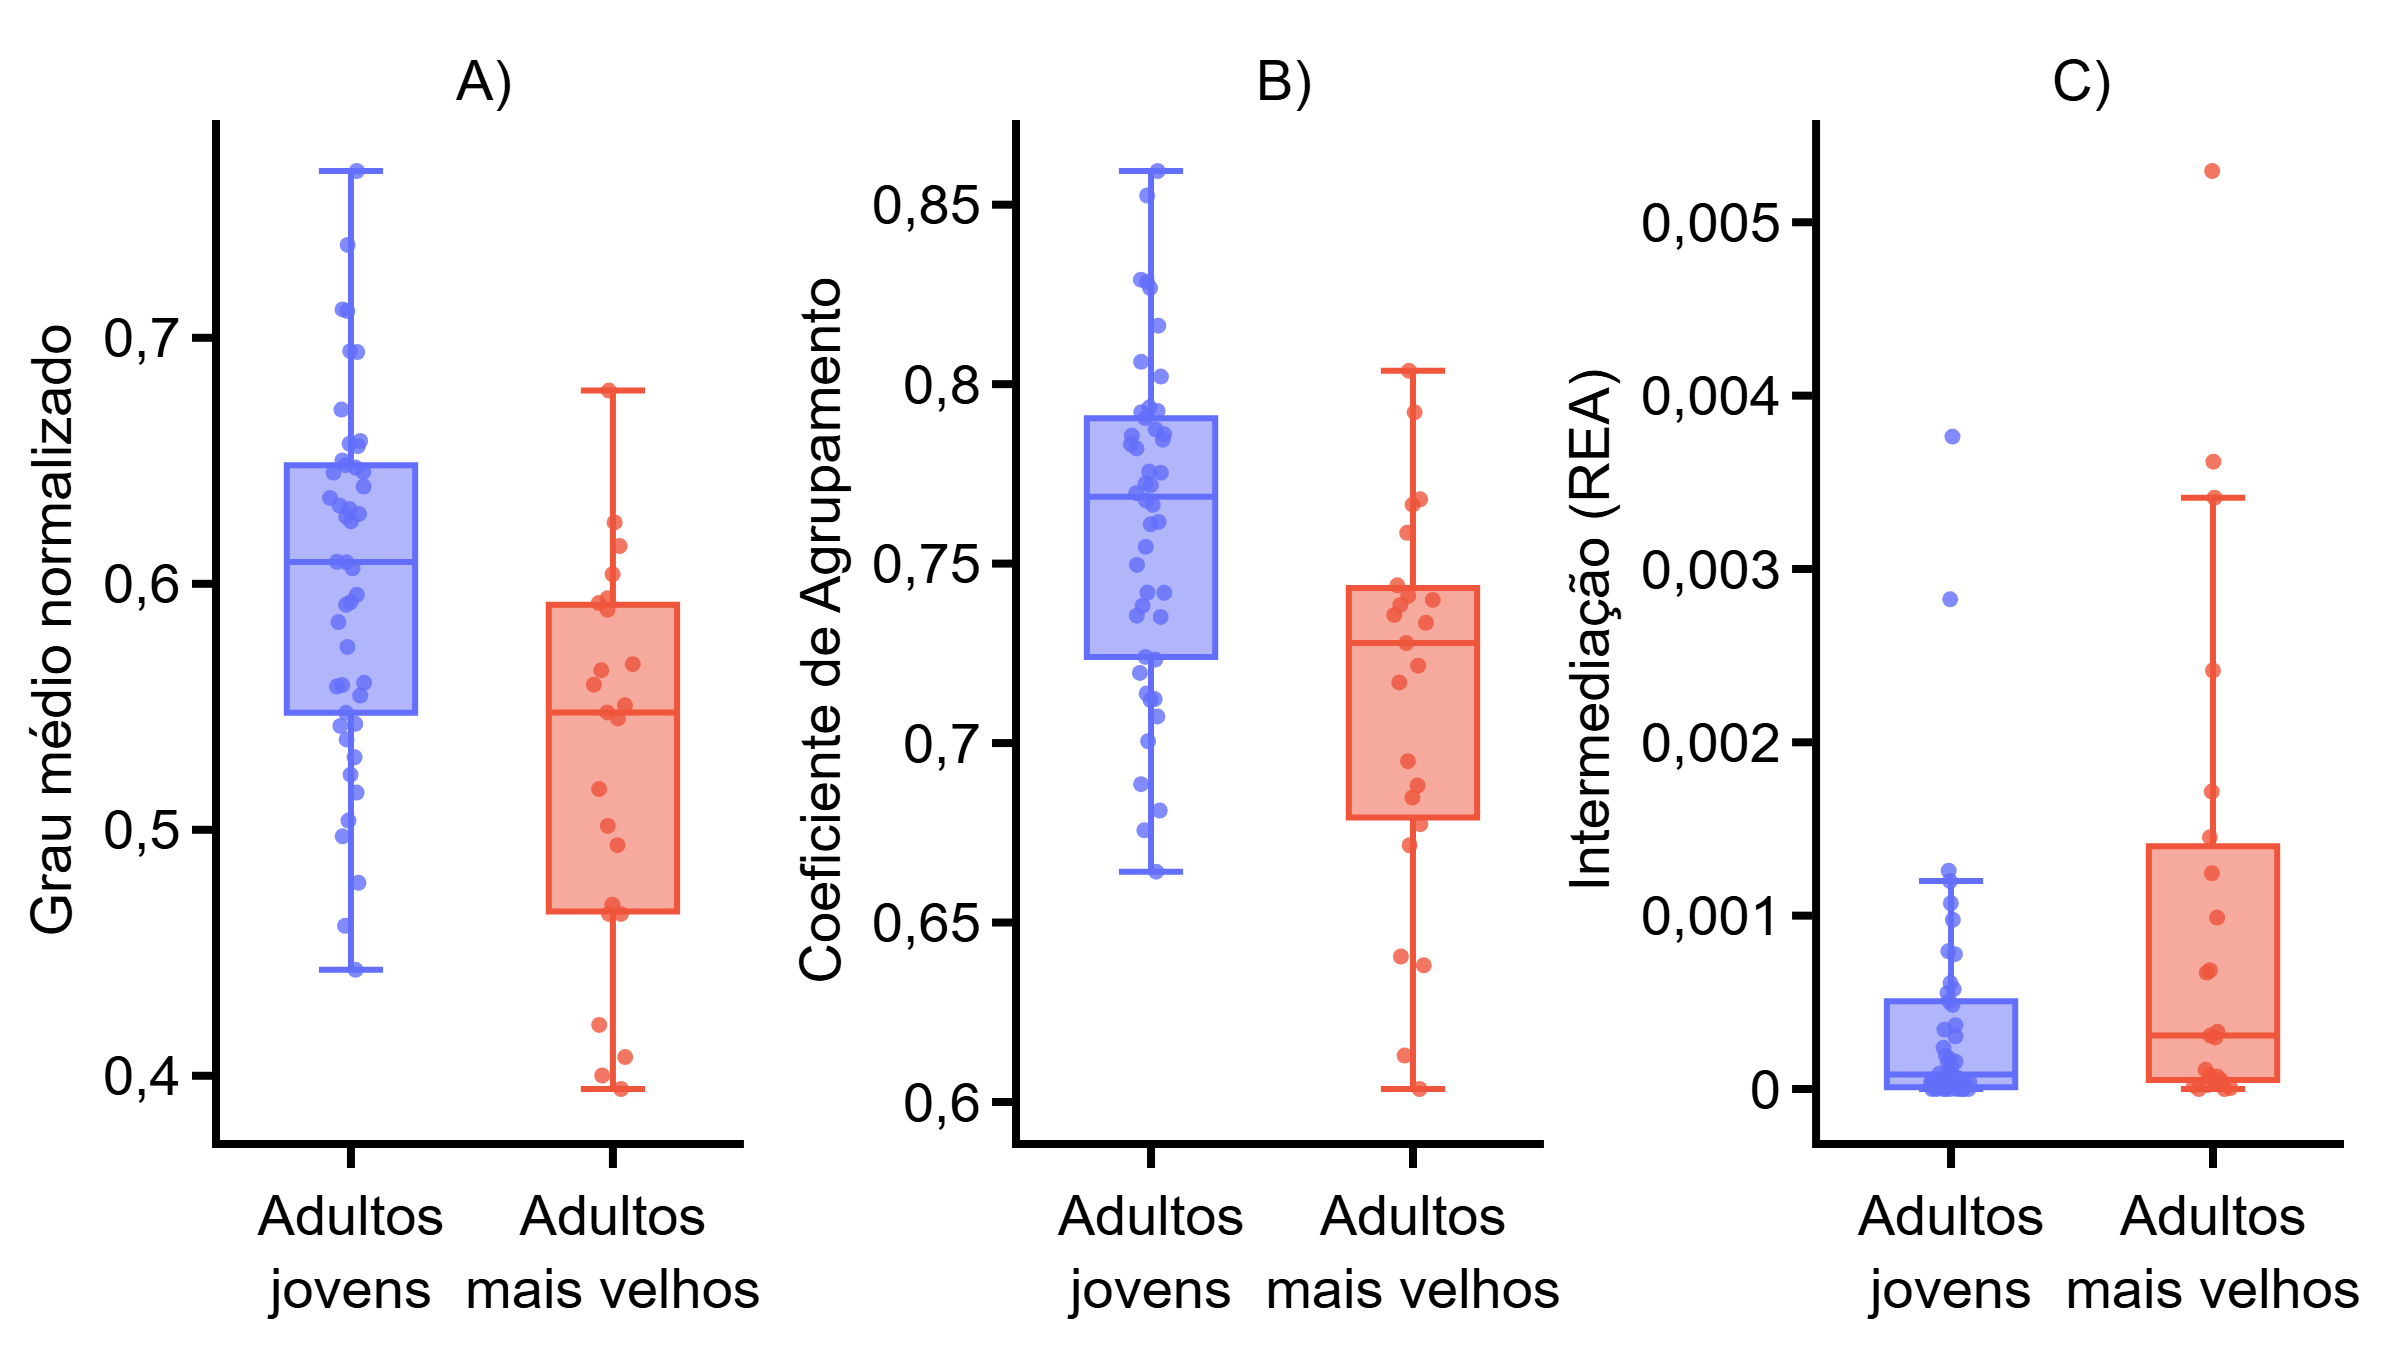

Salvo: ..\..\figures\amostra_ampliada\fig6_metricas_idade_n69.png


In [4]:
AGE_PANELS = [
    ("m_degree", "Grau médio normalizado", "A"),
    ("m_bin_clustering", "Coeficiente de Agrupamento", "B"),
    ("m_betweenness", "Intermediação (REA)", "C"),
]
AGE_LABELS = {"young": "Adultos jovens", "older": "Adultos mais velhos"}
AGE_COLORS = {"Adultos jovens": "#636EFA", "Adultos mais velhos": "#EF553B"}

for name, df in samples.items():
    n = df["subject_id"].nunique()
    print(LABEL[name])
    per_participant = (
        df.groupby(["subject_id", "age_group"], as_index=False)[[m for m, _, _ in AGE_PANELS]].mean()
        .assign(grupo=lambda d: d["age_group"].map(AGE_LABELS))
    )
    fig6 = make_subplots(rows=1, cols=3, horizontal_spacing=0.13, subplot_titles=[f"{tag})" for _, _, tag in AGE_PANELS])
    for col, (metric, ylabel, _) in enumerate(AGE_PANELS, start=1):
        for grupo, color in AGE_COLORS.items():
            sub = per_participant[per_participant["grupo"] == grupo]
            fig6.add_trace(
                go.Box(x=sub["grupo"].str.replace(" ", "<br>", n=1), y=sub[metric], name=grupo,
                       marker=dict(color=color, size=4, opacity=0.8), line=dict(color=color, width=1.5),
                       boxpoints="all", jitter=0.35, pointpos=0, showlegend=False),
                row=1, col=col,
            )
        fig6.update_yaxes(title_text=ylabel, title_standoff=4, row=1, col=col)
    fig6.update_layout(margin=dict(l=55, r=10, t=30, b=40))
    save_and_show(fig6, f"fig6_metricas_idade_n{n}", height=340)

### PCA das métricas locais (texto da Seção de PCA)

Mesmo procedimento de `02_pca/03` e `04`: métricas locais dos 53 eletrodos (grau, agrupamento, intermediação e frequência de hub), exclusão de colunas constantes ou duplicadas, imputação pela mediana, padronização e PCA nos registros EO e EC. A contribuição de cada família é a soma das cargas ao quadrado na componente.

O sinal de uma componente principal é arbitrário. Para que as medianas da Tabela 3 sejam comparáveis, a PC1 da amostra ampliada é orientada no mesmo sentido da amostra principal (mesmo sinal da correlação com o grau médio).

In [5]:
def node_features(df: pd.DataFrame) -> list[str]:
    cols = [c for c in df.columns if c.startswith(NODE_PREFIXES)]
    raw = df[cols]
    constant = {c for c in cols if raw[c].nunique(dropna=True) <= 1}
    duplicated = raw.T.duplicated()
    return [c for c, d in zip(cols, duplicated) if c not in constant and not d]


def run_pca(df: pd.DataFrame) -> dict:
    feats = node_features(df)
    pipe = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler()), ("pca", PCA())])
    scores = pipe.fit_transform(df[feats])
    pca = pipe["pca"]
    loadings = pd.DataFrame(pca.components_[:2].T, index=feats, columns=["PC1", "PC2"])
    pc1 = pd.Series(scores[:, 0], index=df.index)
    return {
        "n_features": len(feats),
        "variance": pca.explained_variance_ratio_,
        "loadings": loadings,
        "pc1": pc1,
        "sign_degree": np.sign(np.corrcoef(pc1, df["m_degree"])[0, 1]),
    }


pca_res = {k: run_pca(df) for k, df in samples.items()}
ref_sign = pca_res["principal"]["sign_degree"]
for k, res in pca_res.items():
    flip = res["sign_degree"] != ref_sign
    if flip:
        res["pc1"] = -res["pc1"]
        res["loadings"]["PC1"] = -res["loadings"]["PC1"]
    print(f"{LABEL[k]}: PC1 {'invertida' if flip else 'mantida'}")


def pca_summary(res: dict) -> pd.Series:
    lt = res["loadings"].assign(tipo=[c.rsplit("_", 1)[0] for c in res["loadings"].index])
    contrib = lt.groupby("tipo")["PC1"].apply(lambda s: (s ** 2).sum())
    mean_load = lt.groupby("tipo")["PC1"].mean()
    out = {
        "Variáveis no PCA": f"{res['n_features']}",
        "Variância explicada PC1": fmt_num(res["variance"][0], ".1%"),
        "Variância explicada PC2": fmt_num(res["variance"][1], ".1%"),
    }
    for tipo in contrib.sort_values(ascending=False).index:
        out[f"PC1: contribuição de {tipo}"] = fmt_num(contrib[tipo], ".1%")
    for tipo in contrib.sort_values(ascending=False).index:
        out[f"PC1: carga média de {tipo}"] = fmt_num(mean_load[tipo], "+.3f")
    return pd.Series(out)


pd.DataFrame({LABEL[k]: pca_summary(res) for k, res in pca_res.items()})

Amostra principal (n = 54): PC1 mantida
Amostra ampliada (n = 69): PC1 mantida


,Amostra principal (n = 54),Amostra ampliada (n = 69)
Variáveis no PCA,212,212
Variância explicada PC1,"52,8%","52,2%"
Variância explicada PC2,"6,6%","6,0%"
PC1: contribuição de clustering,"43,5%","43,8%"
PC1: contribuição de degree,"40,3%","40,2%"
PC1: contribuição de betweenness,"9,2%","9,3%"
PC1: contribuição de hub_frequency,"7,1%","6,6%"
PC1: carga média de clustering,"+0,091","+0,091"
PC1: carga média de degree,"+0,087","+0,087"
PC1: carga média de betweenness,"-0,040","-0,040"


### Tabela 3: escores de PC1 por grupo etário

Um valor por participante: média de EO e EC e diferença individual EO − EC. Mann–Whitney bilateral; rank-biserial na ordem mais velhos versus jovens.

In [6]:
def pc1_per_subject(df: pd.DataFrame, pc1: pd.Series) -> pd.DataFrame:
    per = (
        df.assign(PC1=pc1)
        .pivot_table(index=["subject_id", "age_group"], columns="condition", values="PC1")
    )
    per["PC1_media"] = per[["EO", "EC"]].mean(axis=1)
    per["PC1_EO_menos_EC"] = per["EO"] - per["EC"]
    return per


TAB3_ROWS = {"PC1_media": "Média de EO e EC por participante", "PC1_EO_menos_EC": "Diferença EO − EC por participante"}
pc1_subj = {k: pc1_per_subject(samples[k], res["pc1"]) for k, res in pca_res.items()}
tab3 = {k: pd.DataFrame({label: group_test(per[col]) for col, label in TAB3_ROWS.items()}).T for k, per in pc1_subj.items()}


def fmt_tab3(t: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame({
        "Mediana jovens": t["Mediana jovens"].map(lambda v: fmt_num(v, ".2f")),
        "Mediana mais velhos": t["Mediana mais velhos"].map(lambda v: fmt_num(v, ".2f")),
        "p": t["p"].map(lambda v: fmt_num(v, ".4f")),
        "Rank-biserial": t["Rank-biserial"].map(lambda v: fmt_num(v, "+.2f")),
    })


side_by_side({k: fmt_tab3(t) for k, t in tab3.items()})

Amostra principal (n = 54)  \
                                               Mediana jovens   
Média de EO e EC por participante                        4,17   
Diferença EO − EC por participante                      -1,39   

                                                                              \
                                   Mediana mais velhos       p Rank-biserial   
Média de EO e EC por participante                -2,29  0,0035         -0,49   
Diferença EO − EC por participante               -6,28  0,0101         -0,43   

                                   Amostra ampliada (n = 69)  \
                                              Mediana jovens   
Média de EO e EC por participante                       4,42   
Diferença EO − EC por participante                     -1,67   

                                                                              
                                   Mediana mais velhos       p Rank-biserial  
Média de EO e EC por participante                -1,99  0,0010         -0,49  
Diferença EO − EC por participante               -6,49  0,0023         -0,45

### Figura 7: escores de PC1 por grupo etário

Uma figura por amostra (`fig7_pc1_idade_n54.png` e `fig7_pc1_idade_n69.png`). A: média de EO e EC por participante; B: diferença EO − EC.

Formatação das Figuras 6 a 8 conforme as normas do TCC: sem título, sem linhas de grade, sem borda e sem preenchimento; eixos em linha preta de 2 px (≈ 1,5 pt) e textos em Arial 14 px. A largura de exportação é 600 px; inserida com 16 cm no documento, a fonte corresponde a ≈ 10,5 pt.

Amostra principal (n = 54)


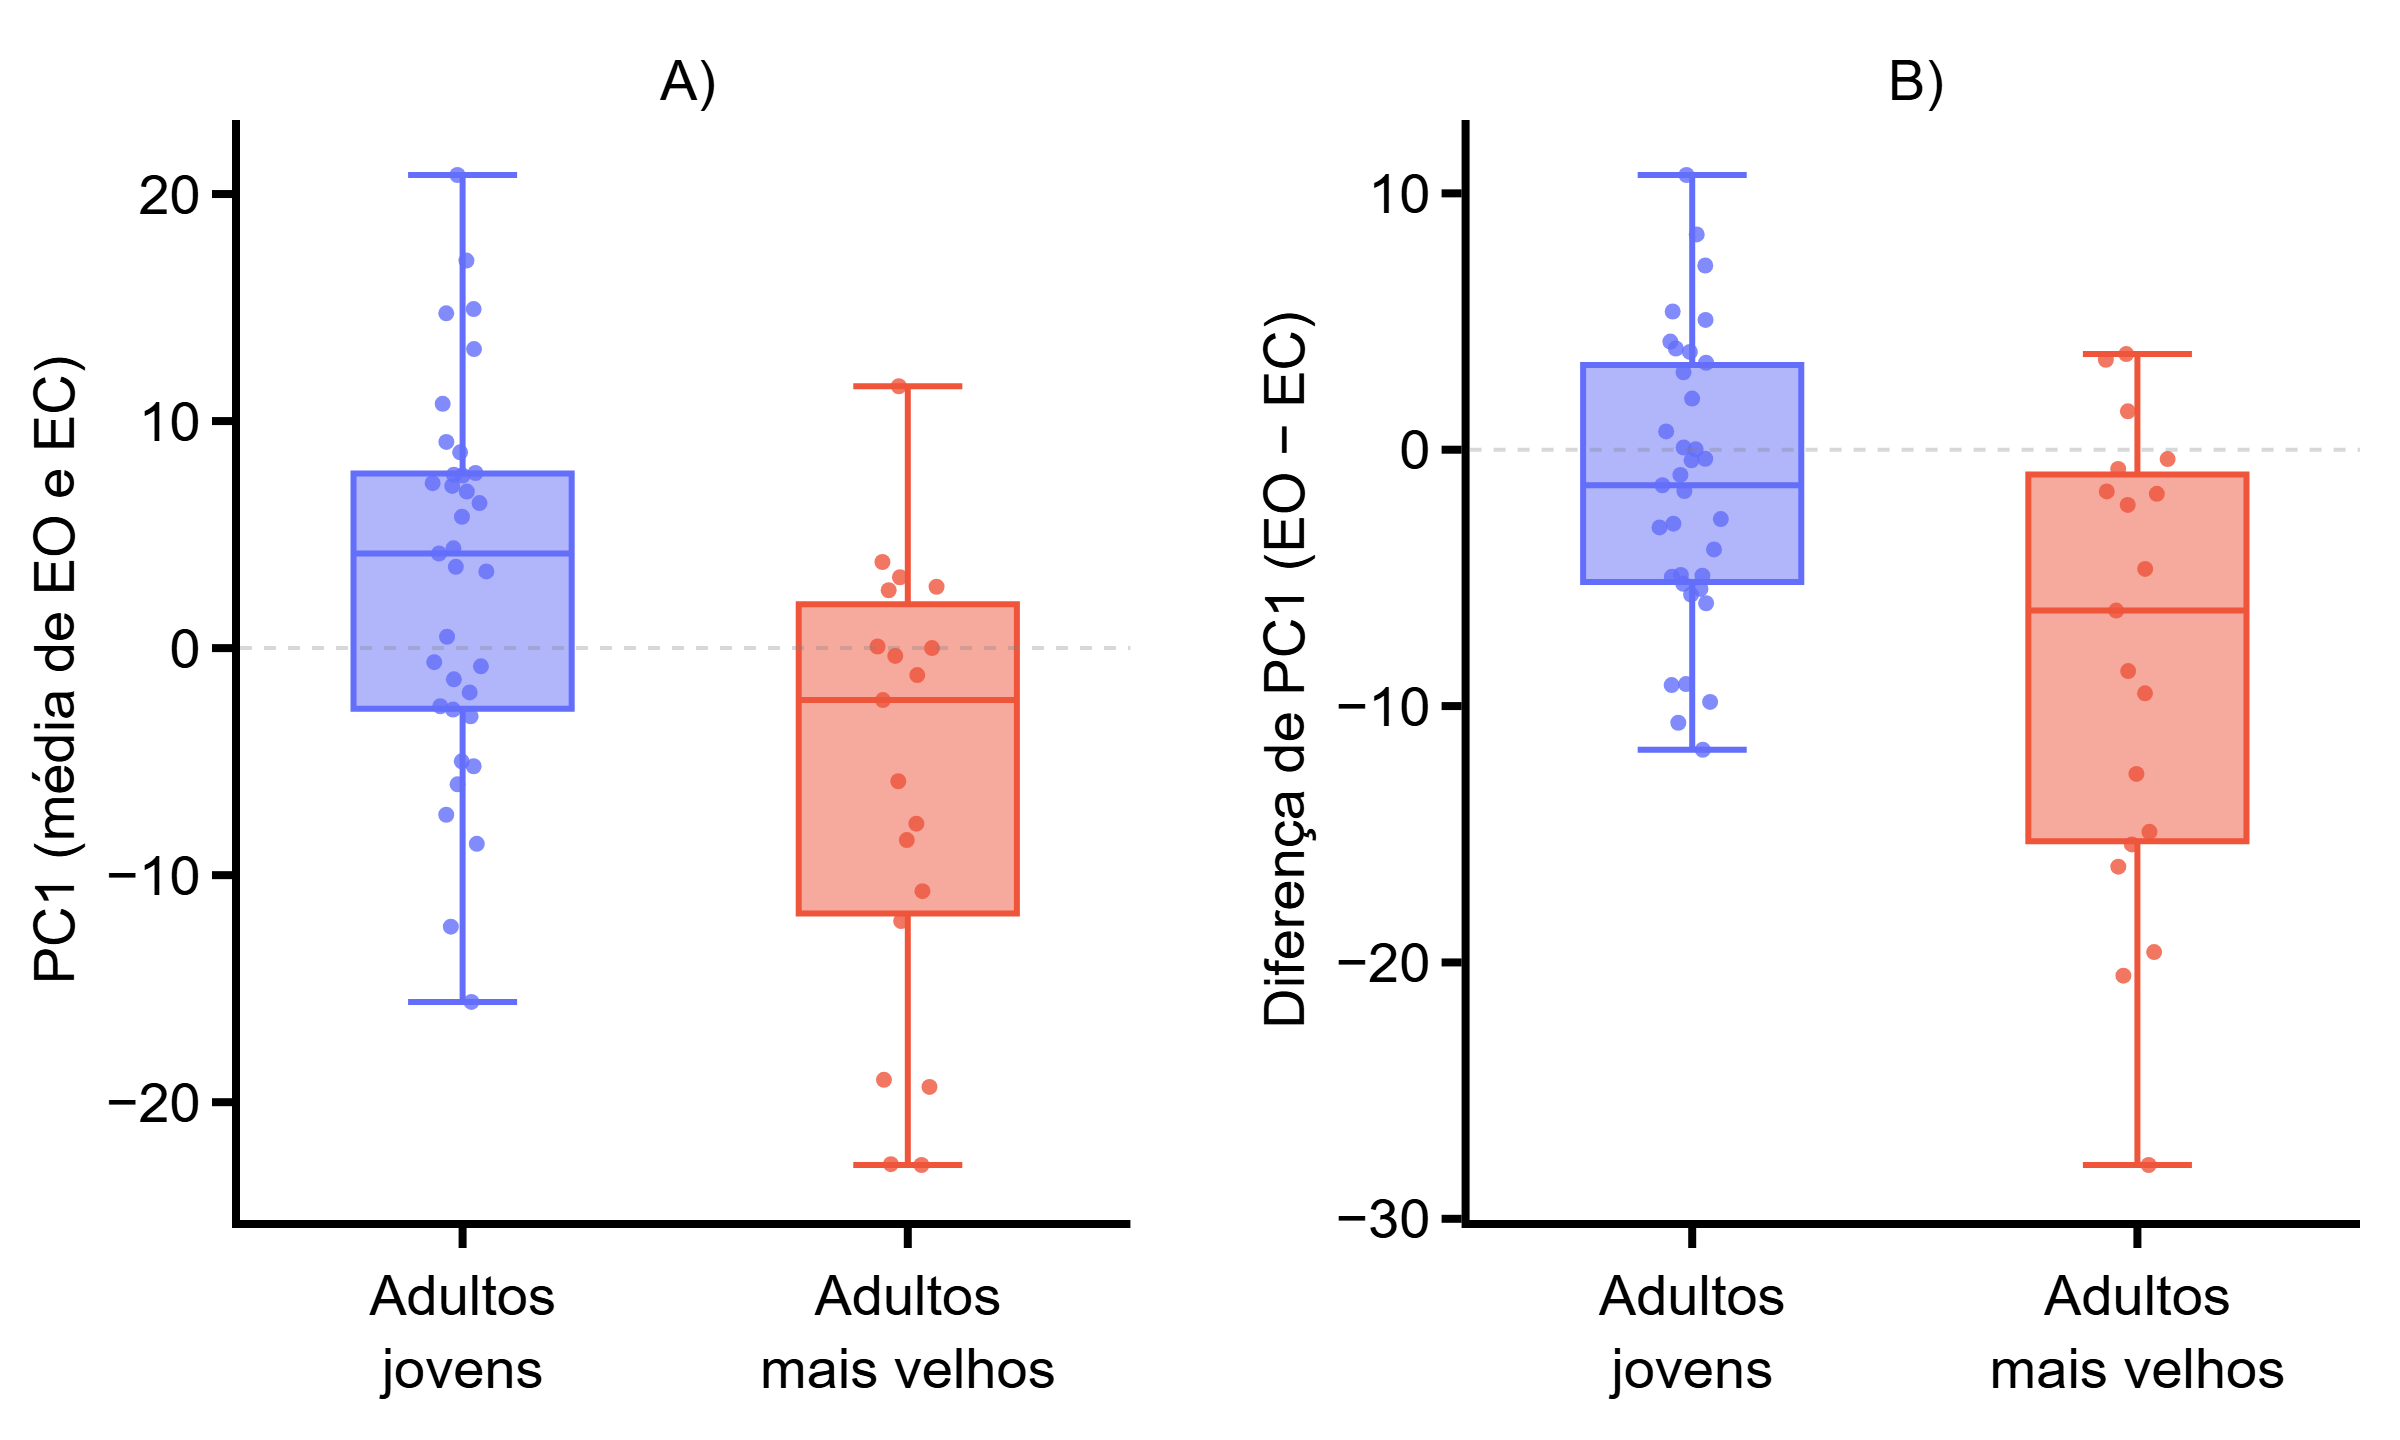

Salvo: ..\..\figures\amostra_ampliada\fig7_pc1_idade_n54.png
Amostra ampliada (n = 69)


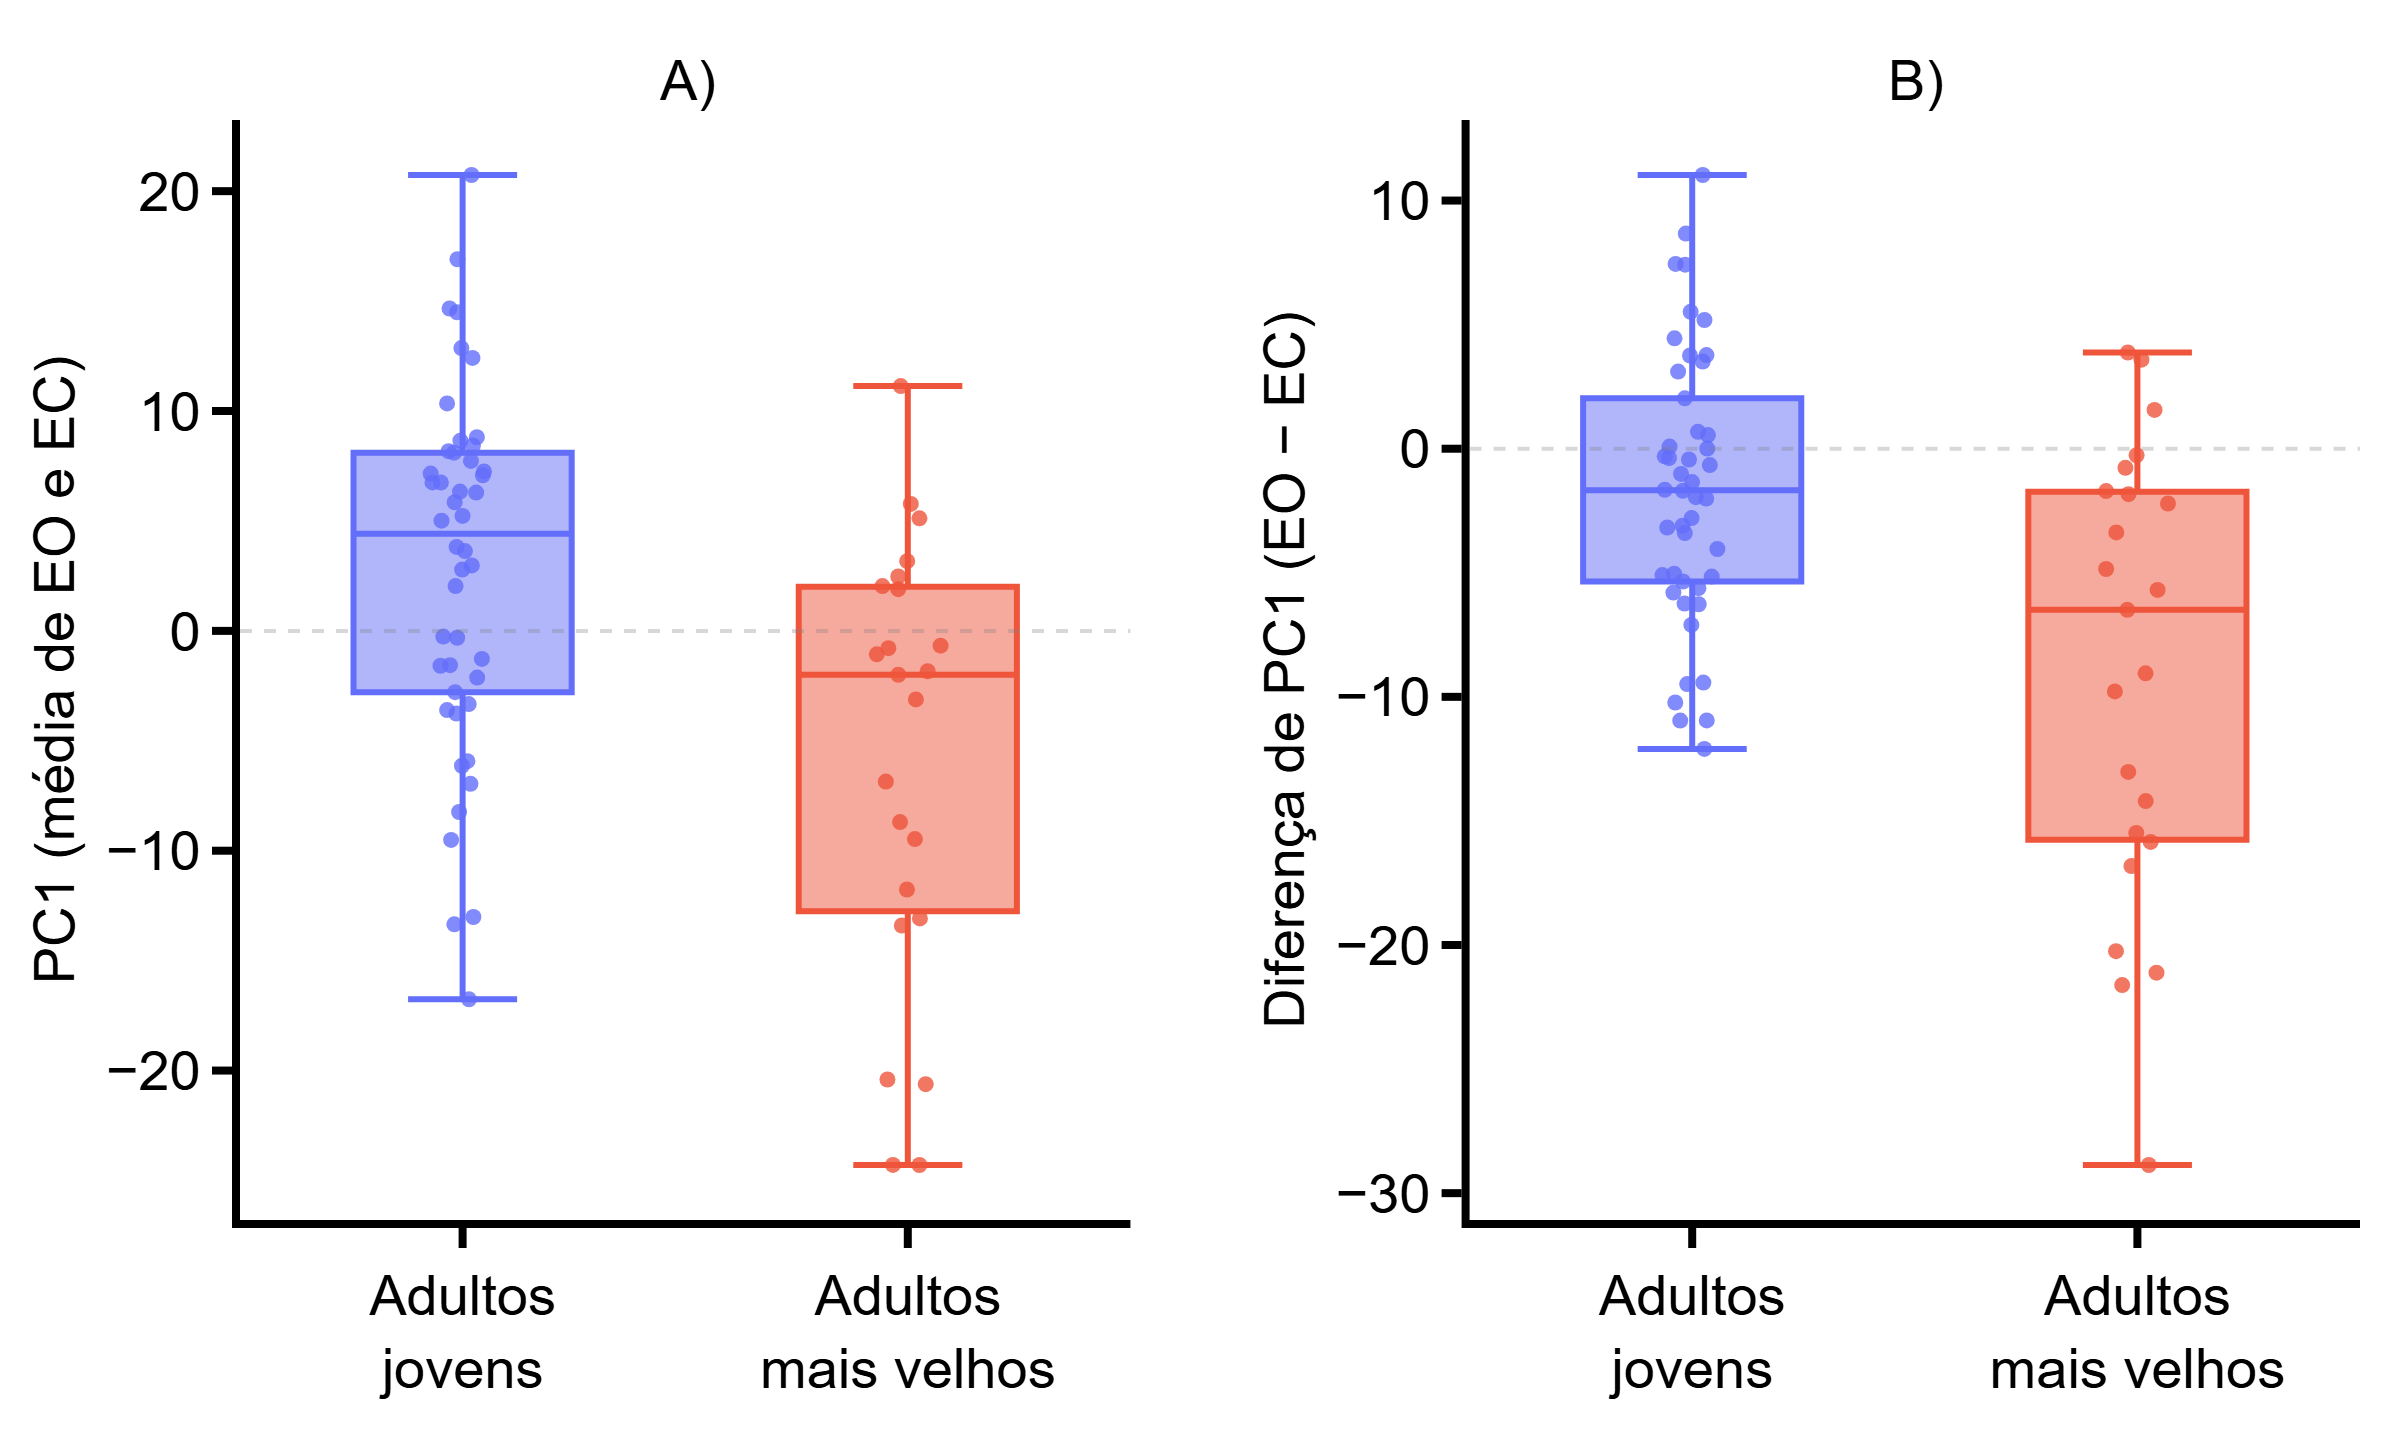

Salvo: ..\..\figures\amostra_ampliada\fig7_pc1_idade_n69.png


In [7]:
for k, per in pc1_subj.items():
    n = samples[k]["subject_id"].nunique()
    print(LABEL[k])
    per = per.reset_index()
    fig7 = make_subplots(rows=1, cols=2, horizontal_spacing=0.16, subplot_titles=["A)", "B)"])
    for col, measure in enumerate(TAB3_ROWS, start=1):
        for grp, color in zip(AGE_LABELS, AGE_COLORS.values()):
            sub = per[per["age_group"] == grp]
            fig7.add_trace(
                go.Box(x=[AGE_LABELS[grp].replace(" ", "<br>", 1)] * len(sub), y=sub[measure], marker=dict(color=color, size=4, opacity=0.8),
                       line=dict(color=color, width=1.5), boxpoints="all", jitter=0.35, pointpos=0, showlegend=False),
                row=1, col=col,
            )
        fig7.update_yaxes(title_text="PC1 (média de EO e EC)" if col == 1 else "Diferença de PC1 (EO − EC)",
                          title_standoff=4, row=1, col=col)
        fig7.add_hline(y=0, line=dict(color="gray", width=1, dash="dot"), row=1, col=col)
    fig7.update_layout(margin=dict(l=60, r=10, t=30, b=40))
    save_and_show(fig7, f"fig7_pc1_idade_n{n}", height=360)

### Tabela 4: classificação dos grupos etários

Mesmo procedimento de `03_classification/07`: um registro por participante, 215 variáveis de rede (212 locais e 3 globais), `StratifiedKFold` com 5 dobras (`random_state = 42`), média ± desvio-padrão das dobras.

In [8]:
def feature_cols(df: pd.DataFrame) -> list[str]:
    cols = [c for c in df.columns if c.startswith(NODE_PREFIXES) or c in GLOBAL_FEATURES]
    return df[cols].select_dtypes(include="number").dropna(axis=1, how="all").columns.tolist()


def condition_matrix(df: pd.DataFrame, condition: str):
    sub = df[df["condition"] == condition].drop_duplicates("subject_id").set_index("subject_id")
    return sub[feature_cols(df)], sub["y"]


def diff_matrix(df: pd.DataFrame):
    X_eo, y_eo = condition_matrix(df, "EO")
    X_ec, _ = condition_matrix(df, "EC")
    common = X_eo.index.intersection(X_ec.index)
    return X_ec.loc[common] - X_eo.loc[common], y_eo.loc[common]


def get_models():
    pre = lambda: [("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]
    return {
        "Dummy": DummyClassifier(strategy="most_frequent"),
        "LogReg_L2": Pipeline(pre() + [("clf", LogisticRegression(max_iter=5000, class_weight="balanced", random_state=RANDOM_STATE))]),
        "SVM_RBF": Pipeline(pre() + [("clf", SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=RANDOM_STATE))]),
        "RandomForest": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)),
        ]),
        "KNN_PCA": Pipeline(pre() + [("pca", PCA(n_components=10, random_state=RANDOM_STATE)), ("clf", KNeighborsClassifier(n_neighbors=5))]),
    }


MODEL_LABELS = {
    "Dummy": "Dummy",
    "LogReg_L2": "Regressão logística",
    "SVM_RBF": "SVM",
    "RandomForest": "Random Forest",
    "KNN_PCA": "KNN com PCA",
}
TAB4_COLUMNS = {
    ("EO", "balanced_accuracy"): "Acurácia balanceada em EO",
    ("EO", "roc_auc"): "ROC-AUC em EO",
    ("EC", "roc_auc"): "ROC-AUC em EC",
    ("Diff", "roc_auc"): "ROC-AUC em EC − EO",
}


def classification_table(df: pd.DataFrame) -> pd.DataFrame:
    tasks = {"EO": condition_matrix(df, "EO"), "EC": condition_matrix(df, "EC"), "Diff": diff_matrix(df)}
    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    scores = {}
    for task, (X, y) in tasks.items():
        for name, model in get_models().items():
            s = cross_validate(model, X, y, cv=cv, scoring=["balanced_accuracy", "roc_auc"])
            scores[(task, name)] = s
    rows = {}
    for (task, metric), label in TAB4_COLUMNS.items():
        rows[label] = {
            MODEL_LABELS[m]: f"{np.mean(scores[(task, m)][f'test_{metric}']):.3f} ± {np.std(scores[(task, m)][f'test_{metric}']):.3f}".replace(".", ",")
            for m in MODEL_LABELS
        }
    return pd.DataFrame(rows).rename_axis("Modelo")


tab4 = {k: classification_table(df) for k, df in samples.items()}
for k, t in tab4.items():
    print(LABEL[k])
    display(t)

C:\Users\Anne\OneDrive\Documentos\Google Drive\Ciência de Dados\MBA USP\TCC\Código\TCC\venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning:

`sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.

C:\Users\Anne\OneDrive\Documentos\Google Drive\Ciência de Dados\MBA USP\TCC\Código\TCC\venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning:

`sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.

C:\Users\Anne\OneDrive\Documentos\Google Drive\Ciência de Dados\MBA USP\TCC\Código\TCC\venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning:

`sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn conf

Amostra principal (n = 54)


,Acurácia balanceada em EO,ROC-AUC em EO,ROC-AUC em EC,ROC-AUC em EC − EO
Modelo,,,,
Dummy,"0,500 ± 0,000","0,500 ± 0,000","0,500 ± 0,000","0,500 ± 0,000"
Regressão logística,"0,675 ± 0,144","0,714 ± 0,171","0,652 ± 0,197","0,562 ± 0,243"
SVM,"0,707 ± 0,116","0,757 ± 0,073","0,583 ± 0,156","0,655 ± 0,166"
Random Forest,"0,627 ± 0,123","0,762 ± 0,144","0,661 ± 0,201","0,643 ± 0,090"
KNN com PCA,"0,655 ± 0,089","0,638 ± 0,164","0,652 ± 0,150","0,604 ± 0,101"


Amostra ampliada (n = 69)


,Acurácia balanceada em EO,ROC-AUC em EO,ROC-AUC em EC,ROC-AUC em EC − EO
Modelo,,,,
Dummy,"0,500 ± 0,000","0,500 ± 0,000","0,500 ± 0,000","0,500 ± 0,000"
Regressão logística,"0,586 ± 0,024","0,766 ± 0,049","0,629 ± 0,197","0,666 ± 0,126"
SVM,"0,710 ± 0,078","0,797 ± 0,121","0,633 ± 0,207","0,694 ± 0,143"
Random Forest,"0,706 ± 0,113","0,764 ± 0,157","0,643 ± 0,105","0,674 ± 0,168"
KNN com PCA,"0,599 ± 0,099","0,738 ± 0,137","0,590 ± 0,099","0,628 ± 0,043"


### Tabela 5: testes de permutação em EO

Mesmo procedimento de `03_classification/08`: 5.000 permutações dos rótulos, mesma validação cruzada, p = (1 + nº de nulos ≥ observado) / (N + 1); limite de Bonferroni 0,05/4 = 0,0125. As permutações são geradas na mesma sequência do notebook original e avaliadas em paralelo (resultado idêntico).

In [9]:
PERM_METRICS = ("roc_auc", "balanced_accuracy")


def cv_mean_scores(model, X, y):
    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    s = cross_validate(model, X, y, cv=cv, scoring={m: m for m in PERM_METRICS})
    return [float(np.mean(s[f"test_{m}"])) for m in PERM_METRICS]


def permutation_table(df: pd.DataFrame) -> pd.DataFrame:
    X, y = condition_matrix(df, "EO")
    models = get_models()
    rows = []
    for name in ("LogReg_L2", "SVM_RBF"):
        observed = cv_mean_scores(models[name], X, y)
        rng = np.random.default_rng(RANDOM_STATE)
        perms = [pd.Series(rng.permutation(y.to_numpy()), index=y.index) for _ in range(N_PERM)]
        nulls = np.array(Parallel(n_jobs=-1)(delayed(cv_mean_scores)(models[name], X, yp) for yp in perms))
        for j, metric in enumerate(PERM_METRICS):
            p = (1 + int(np.sum(nulls[:, j] >= observed[j]))) / (N_PERM + 1)
            rows.append({
                "Modelo": MODEL_LABELS[name],
                "Métrica": "ROC-AUC" if metric == "roc_auc" else "Acurácia balanceada",
                "Valor observado": fmt_num(observed[j], ".3f"),
                "p da permutação": fmt_num(p, ".4f"),
                "Significativo (Bonferroni)": "sim" if p < ALPHA_BONF else "não",
            })
    return pd.DataFrame(rows).set_index(["Modelo", "Métrica"])


tab5 = {k: permutation_table(df) for k, df in samples.items()}
side_by_side(tab5)

Amostra principal (n = 54)  \
                                                   Valor observado   
Modelo              Métrica                                          
Regressão logística ROC-AUC                                  0,714   
                    Acurácia balanceada                      0,675   
SVM                 ROC-AUC                                  0,757   
                    Acurácia balanceada                      0,707   

                                                         \
                                        p da permutação   
Modelo              Métrica                               
Regressão logística ROC-AUC                      0,0276   
                    Acurácia balanceada          0,0176   
SVM                 ROC-AUC                      0,0034   
                    Acurácia balanceada          0,0036   

                                                                    \
                                        Significativo (Bonferroni)   
Modelo              Métrica                                          
Regressão logística ROC-AUC                                    não   
                    Acurácia balanceada                        não   
SVM                 ROC-AUC                                    sim   
                    Acurácia balanceada                        sim   

                                        Amostra ampliada (n = 69)  \
                                                  Valor observado   
Modelo              Métrica                                         
Regressão logística ROC-AUC                                 0,766   
                    Acurácia balanceada                     0,586   
SVM                 ROC-AUC                                 0,797   
                    Acurácia balanceada                     0,710   

                                                         \
                                        p da permutação   
Modelo              Métrica                               
Regressão logística ROC-AUC                      0,0034   
                    Acurácia balanceada          0,1264   
SVM                 ROC-AUC                      0,0002   
                    Acurácia balanceada          0,0024   

                                                                    
                                        Significativo (Bonferroni)  
Modelo              Métrica                                         
Regressão logística ROC-AUC                                    sim  
                    Acurácia balanceada                        não  
SVM                 ROC-AUC                                    sim  
                    Acurácia balanceada                        sim

### Figura 8: curva ROC e matriz de confusão (SVM em EO)

Mesmo procedimento de `03_classification/09`: predições fora da amostra (OOF) da SVM-RBF com `decision_function`, 5 dobras estratificadas. Sensibilidade = mais velhos classificados corretamente; especificidade = jovens classificados corretamente.

Uma figura por amostra (`fig8_svm_roc_confusao_n54.png` e `fig8_svm_roc_confusao_n69.png`). A: curva ROC; B: matriz de confusão.

In [10]:
def make_svm():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", class_weight="balanced", probability=False, random_state=RANDOM_STATE)),
    ])


def oof_svm(df: pd.DataFrame) -> dict:
    X, y = condition_matrix(df, "EO")
    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    y_pred = cross_val_predict(make_svm(), X, y, cv=cv)
    y_score = cross_val_predict(make_svm(), X, y, cv=cv, method="decision_function")
    cm = confusion_matrix(y, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    fpr, tpr, _ = roc_curve(y, y_score)
    return {"cm": cm, "fpr": fpr, "tpr": tpr, "auc": roc_auc_score(y, y_score),
            "bal": balanced_accuracy_score(y, y_pred), "sens": tp / (tp + fn), "spec": tn / (tn + fp),
            "tn": tn, "fp": fp, "fn": fn, "tp": tp}


oof = {k: oof_svm(df) for k, df in samples.items()}
pd.DataFrame({
    LABEL[k]: {
        "ROC-AUC OOF": fmt_num(o["auc"], ".3f"),
        "Acurácia balanceada OOF": fmt_num(o["bal"], ".3f"),
        "Sensibilidade (mais velhos)": f"{fmt_num(o['sens'], '.3f')} ({o['tp']}/{o['tp'] + o['fn']})",
        "Especificidade (jovens)": f"{fmt_num(o['spec'], '.3f')} ({o['tn']}/{o['tn'] + o['fp']})",
        "Matriz [VN, FP; FN, VP]": f"[{o['tn']}, {o['fp']}; {o['fn']}, {o['tp']}]",
    }
    for k, o in oof.items()
})

,Amostra principal (n = 54),Amostra ampliada (n = 69)
ROC-AUC OOF,"0,716","0,768"
Acurácia balanceada OOF,"0,699","0,707"
Sensibilidade (mais velhos),"0,684 (13/19)","0,696 (16/23)"
Especificidade (jovens),"0,714 (25/35)","0,717 (33/46)"
"Matriz [VN, FP; FN, VP]","[25, 10; 6, 13]","[33, 13; 7, 16]"


Amostra principal (n = 54)


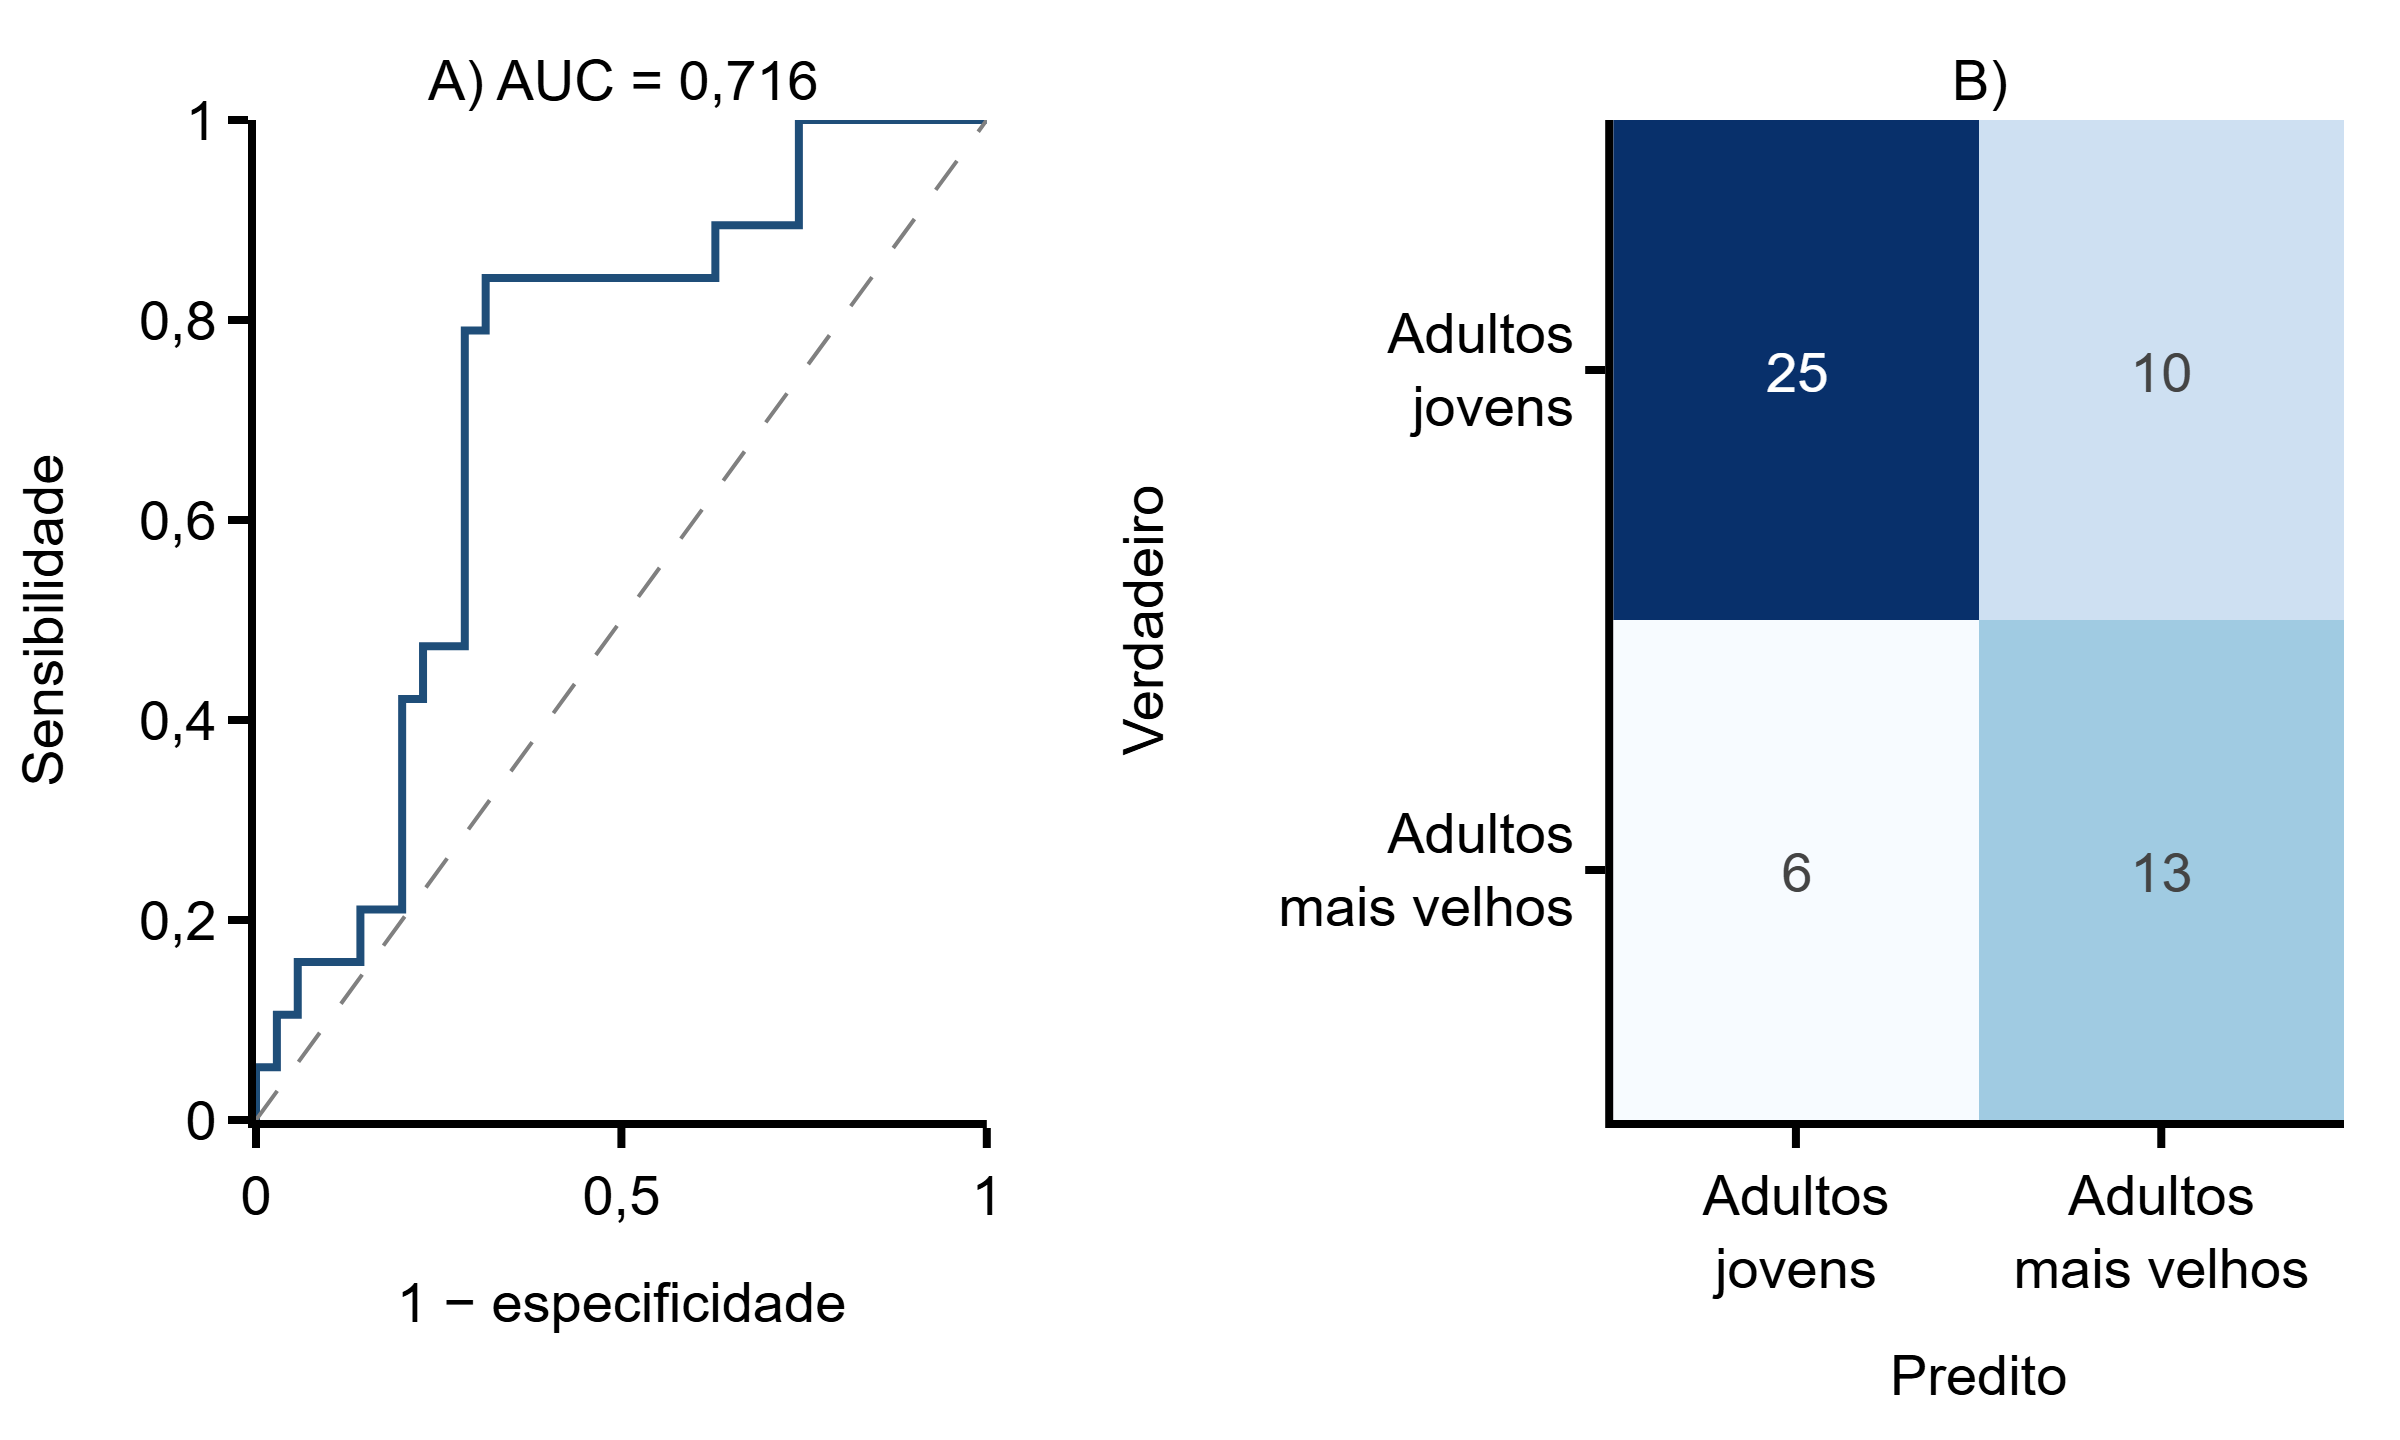

Salvo: ..\..\figures\amostra_ampliada\fig8_svm_roc_confusao_n54.png
Amostra ampliada (n = 69)


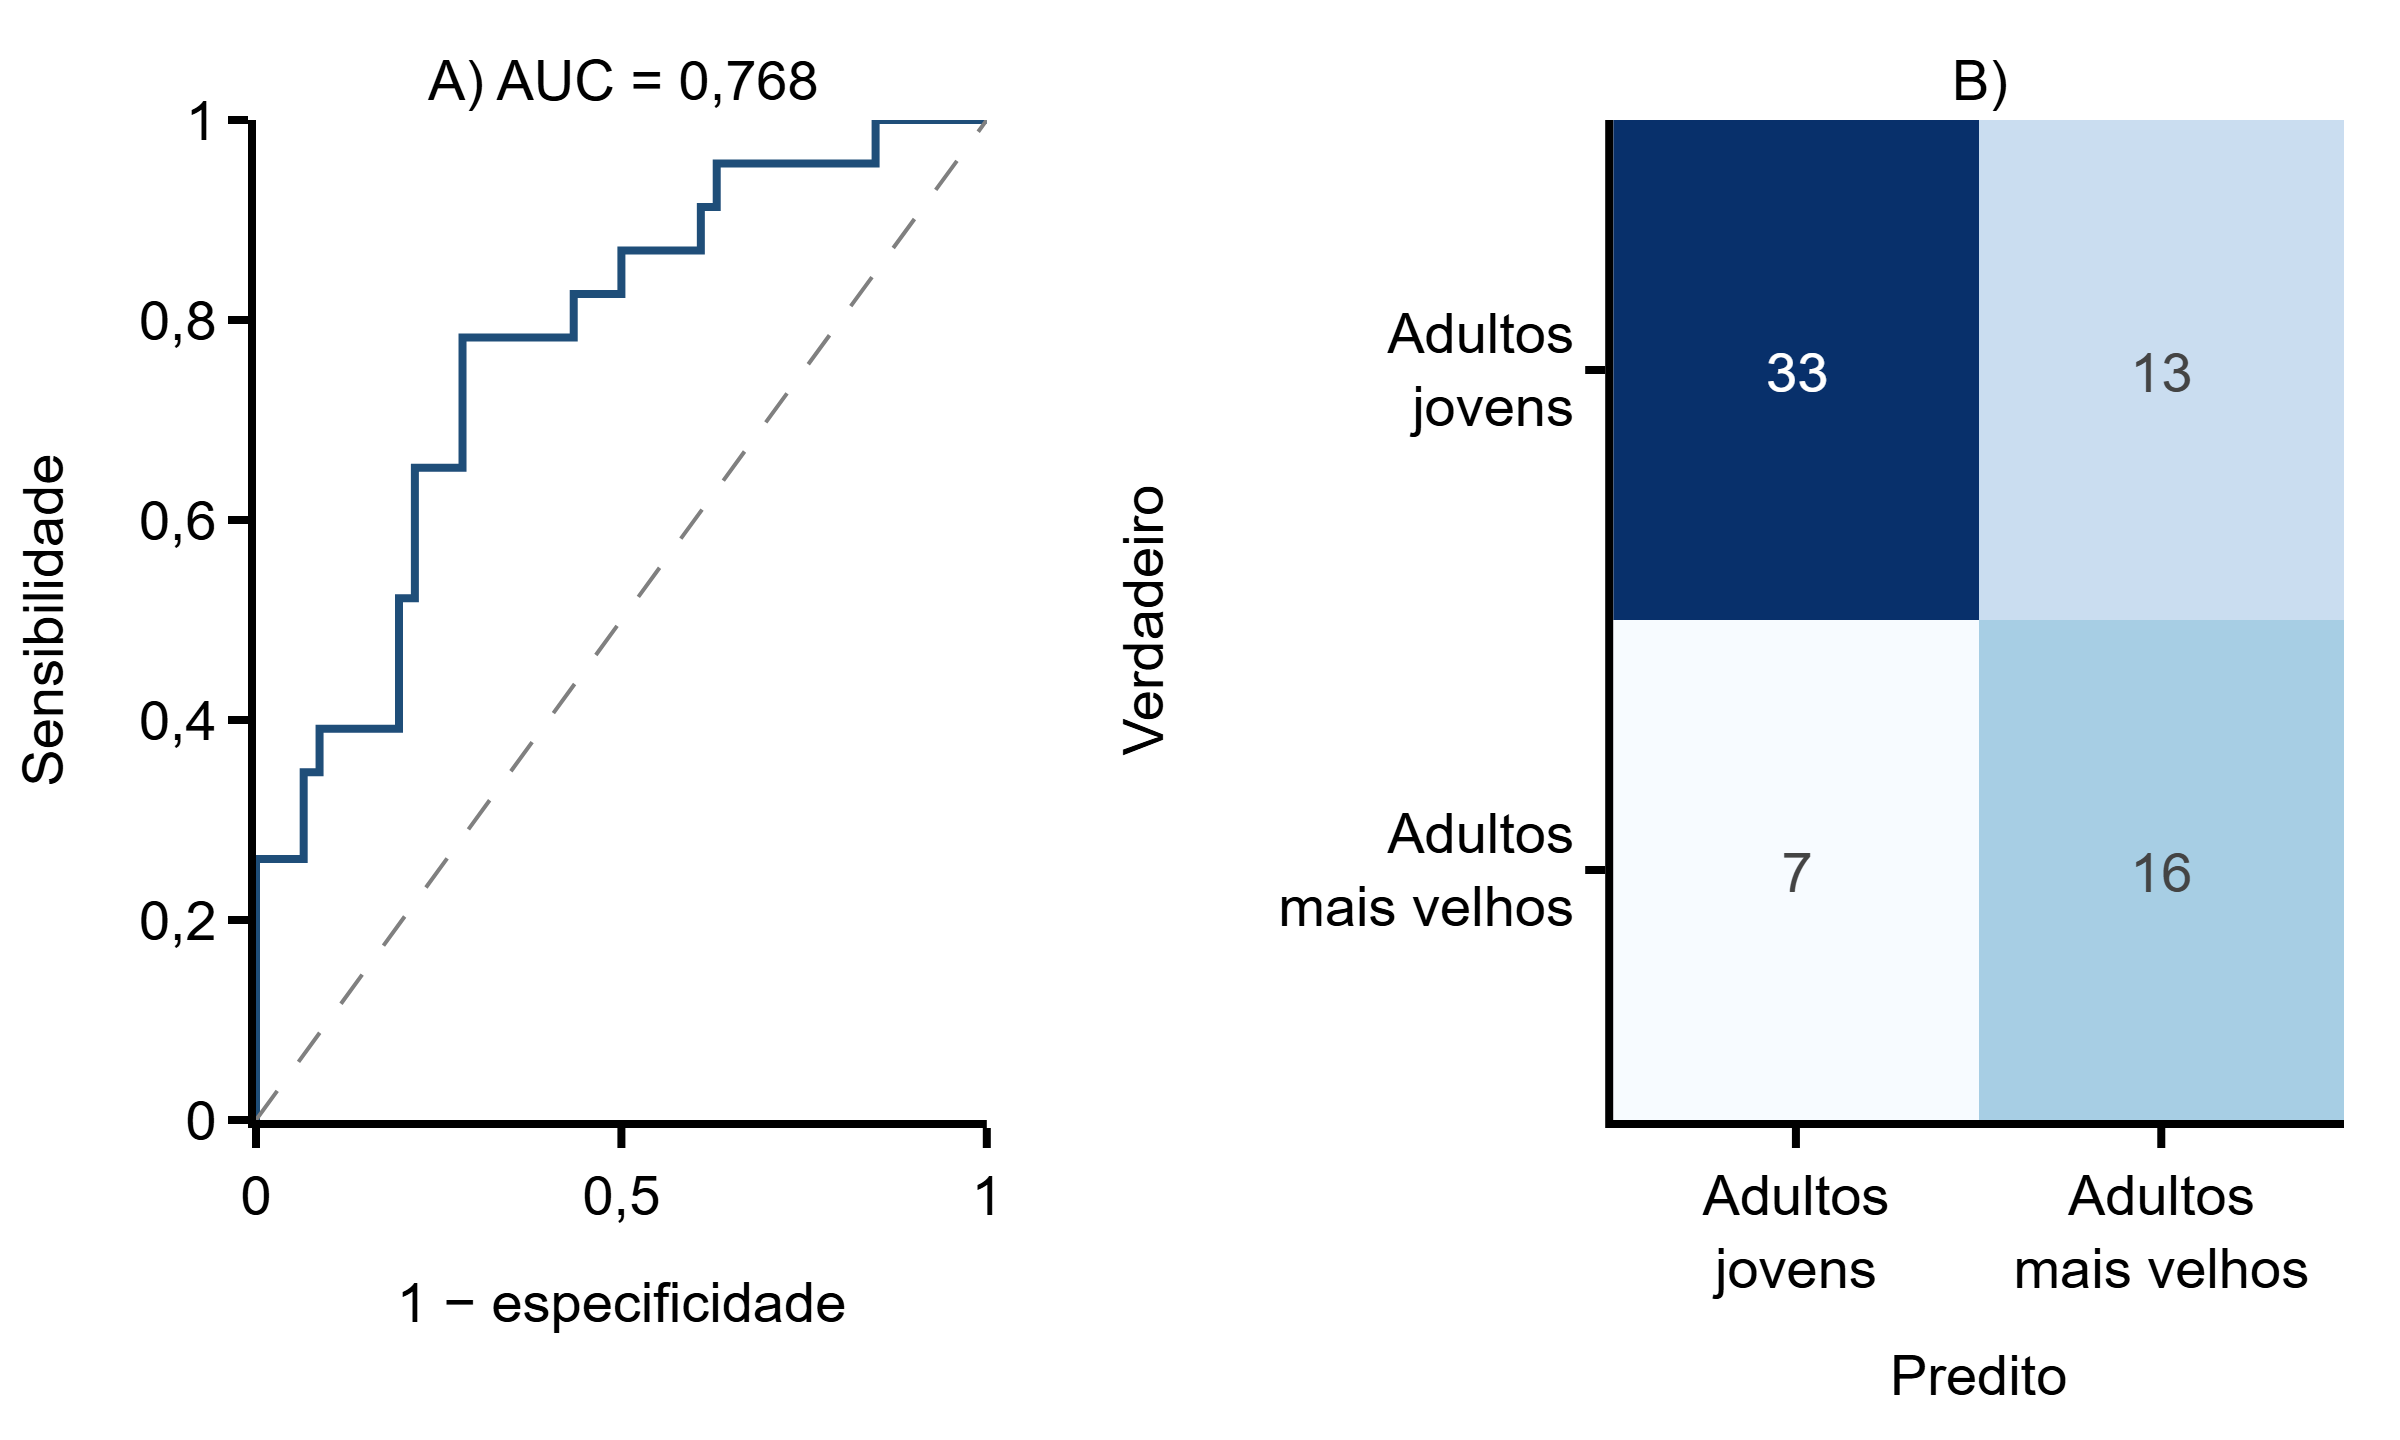

Salvo: ..\..\figures\amostra_ampliada\fig8_svm_roc_confusao_n69.png


In [11]:
CLASS_LABELS = ["Adultos<br>jovens", "Adultos<br>mais velhos"]
for k, o in oof.items():
    n = samples[k]["subject_id"].nunique()
    print(LABEL[k])
    titles = [f"A) AUC = {o['auc']:.3f}".replace(".", ","), "B)"]
    fig8 = make_subplots(rows=1, cols=2, horizontal_spacing=0.3, subplot_titles=titles)
    fig8.add_trace(go.Scatter(x=o["fpr"], y=o["tpr"], mode="lines", line=dict(color="#1f4e79", width=2), showlegend=False), row=1, col=1)
    fig8.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode="lines", line=dict(color="gray", dash="dash", width=1), showlegend=False), row=1, col=1)
    fig8.add_trace(go.Heatmap(z=o["cm"], x=CLASS_LABELS, y=CLASS_LABELS, text=o["cm"], texttemplate="%{text}",
                              textfont=dict(family="Arial", size=14), colorscale="Blues", showscale=False), row=1, col=2)
    fig8.update_xaxes(title_text="1 − especificidade", range=[0, 1], row=1, col=1)
    fig8.update_yaxes(title_text="Sensibilidade", range=[0, 1], row=1, col=1)
    fig8.update_xaxes(title_text="Predito", row=1, col=2)
    fig8.update_yaxes(title_text="Verdadeiro", title_standoff=25, automargin=True, autorange="reversed", row=1, col=2)
    fig8.update_layout(margin=dict(l=60, r=10, t=30, b=45))
    save_and_show(fig8, f"fig8_svm_roc_confusao_n{n}", height=360)

### Análises complementares citadas no texto (SVM em EO)

- **Validação cruzada repetida:** `RepeatedStratifiedKFold` 5 × 20; média e desvio-padrão das 20 médias de repetição.
- **Metadados:** ROC-AUC com só métricas de rede, só gênero e escolaridade, e a combinação (sem teste comparativo formal).
- **Importância por família:** queda média de ROC-AUC ao permutar uma família de variáveis no conjunto de teste (100 permutações por dobra).

In [12]:
def normalize_education(s: pd.Series) -> pd.Series:
    return s.astype(str).str.strip().str.lower().replace(EDUCATION_FIX)


def encode_meta(frame: pd.DataFrame) -> pd.DataFrame:
    parts = []
    for c in ("gender", "education"):
        s = normalize_education(frame[c]) if c == "education" else frame[c]
        if pd.api.types.is_numeric_dtype(s):
            parts.append(s.astype(float).to_frame())
        else:
            parts.append(pd.get_dummies(s.astype(str), prefix=c).astype(float))
    return pd.concat(parts, axis=1)


def auc_decision(est, Xb, yb):
    return float(roc_auc_score(yb, est.decision_function(Xb)))


def complementary(df: pd.DataFrame) -> pd.Series:
    X, y = condition_matrix(df, "EO")
    cols = X.columns.tolist()
    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    out = {}

    rcv = RepeatedStratifiedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=RANDOM_STATE)
    folds = cross_validate(make_svm(), X, y, cv=rcv, scoring="roc_auc")["test_score"]
    rep = folds.reshape(N_REPEATS, N_SPLITS).mean(axis=1)
    out["CV repetida 5 × 20: ROC-AUC"] = f"{fmt_num(rep.mean(), '.3f')} ± {fmt_num(rep.std(), '.3f')}"
    out["CV repetida: intervalo das médias"] = f"{fmt_num(rep.min(), '.3f')} a {fmt_num(rep.max(), '.3f')}"

    eo = df[df["condition"] == "EO"].drop_duplicates("subject_id").set_index("subject_id")
    X_meta = encode_meta(eo).loc[X.index]
    for label, Xb in (("só rede", X), ("só gênero e escolaridade", X_meta), ("rede + metadados", pd.concat([X, X_meta], axis=1))):
        s = cross_validate(make_svm(), Xb, y, cv=cv, scoring="roc_auc")["test_score"]
        out[f"ROC-AUC {label}"] = f"{fmt_num(s.mean(), '.3f')} ± {fmt_num(s.std(), '.3f')}"

    fitted = []
    for train_idx, test_idx in cv.split(X, y):
        est = make_svm().fit(X.iloc[train_idx], y.iloc[train_idx])
        X_te, y_te = X.iloc[test_idx], y.iloc[test_idx]
        fitted.append((est, auc_decision(est, X_te, y_te), X_te, y_te))
    rng = np.random.default_rng(RANDOM_STATE)
    for family, keys in FEATURE_FAMILIES.items():
        fam_cols = [c for c in cols if c in keys] if family == "global" else [c for c in cols if c.startswith(keys)]
        drops = []
        for est, base, X_te, y_te in fitted:
            for _ in range(N_PERM_IMPORTANCE):
                Xp = X_te.copy()
                Xp.loc[:, fam_cols] = Xp.iloc[rng.permutation(len(Xp))][fam_cols].to_numpy()
                drops.append(base - auc_decision(est, Xp, y_te))
        out[f"Importância (Δ ROC-AUC): {family}"] = f"{fmt_num(np.mean(drops), '+.3f')} ± {fmt_num(np.std(drops), '.3f')}"
    return pd.Series(out)


pd.DataFrame({LABEL[k]: complementary(df) for k, df in samples.items()})

,Amostra principal (n = 54),Amostra ampliada (n = 69)
CV repetida 5 × 20: ROC-AUC,"0,762 ± 0,029","0,765 ± 0,025"
CV repetida: intervalo das médias,"0,693 a 0,800","0,698 a 0,798"
ROC-AUC só rede,"0,757 ± 0,073","0,797 ± 0,121"
ROC-AUC só gênero e escolaridade,"0,693 ± 0,173","0,751 ± 0,058"
ROC-AUC rede + metadados,"0,757 ± 0,076","0,811 ± 0,113"
Importância (Δ ROC-AUC): degree,"+0,061 ± 0,113","+0,080 ± 0,111"
Importância (Δ ROC-AUC): clustering,"+0,059 ± 0,108","+0,063 ± 0,104"
Importância (Δ ROC-AUC): betweenness,"+0,008 ± 0,081","+0,030 ± 0,048"
Importância (Δ ROC-AUC): hub_frequency,"+0,008 ± 0,068","+0,065 ± 0,083"
Importância (Δ ROC-AUC): global,"+0,006 ± 0,023","+0,003 ± 0,023"


### Síntese

A coluna da amostra principal reproduz exatamente os números atuais do TCC (Tabelas 2 a 5, Figuras 6 a 8 e análises complementares). A ampliação para 69 participantes (+11 jovens e +4 mais velhos) **mantém todas as conclusões** e, em geral, as torna mais firmes:

- **Tabela 2:** grau, agrupamento binário e agrupamento ponderado continuam menores nos mais velhos, com efeitos praticamente iguais (rank-biserial ≈ −0,50) e p_FDR menor (0,0056 → 0,0017). Variabilidade do grau e intermediação seguem sem significância após FDR. Na interação EO − EC, as cinco métricas seguem significativas, agora com p_FDR ≤ 0,019.
- **PCA:** a PC1 explica 52,2% da variância (52,8% antes), com a mesma composição (agrupamento ≈ 44% e grau ≈ 40% da soma das cargas ao quadrado) e a mesma orientação.
- **Tabela 3:** a PC1 continua menor nos mais velhos, tanto na média de EO e EC (p = 0,0010; rank-biserial −0,49) quanto na diferença EO − EC (p = 0,0023; −0,45).
- **Tabela 4:** em EO, a SVM tem a maior ROC-AUC (0,797) e a maior acurácia balanceada (0,710). A regressão logística ganha ROC-AUC (0,766), mas sua acurácia balanceada cai (0,586). EC e EC − EO seguem abaixo de EO.
- **Tabela 5:** a SVM continua significativa após Bonferroni nas duas métricas (ROC-AUC p = 0,0002; acurácia balanceada p = 0,0024). A ROC-AUC da regressão logística passa a ser significativa (p = 0,0034), mas sua acurácia balanceada não (p = 0,126).
- **Figura 8:** ROC-AUC OOF de 0,768 (0,716 antes), sensibilidade de 0,696 (16/23) e especificidade de 0,717 (33/46).
- **Complementares:** a CV repetida fica praticamente igual (0,765 ± 0,025). Os metadados sozinhos chegam a ROC-AUC 0,751 (0,693 antes), o que reforça a cautela quanto à escolaridade como possível confundidor. Grau e agrupamento seguem entre as famílias mais importantes, agora acompanhados de frequência de hub, sempre com alta variabilidade.
